In [1]:
import numpy as np
from matplotlib import pyplot as plt

## Ridge Regularization

In [ ]:
X = np.random.randn(100, 5)
X = np.hstack((np.ones((100, 1)), X))
y = 2 + 3*X[:,1] - 1.5*X[:,2] + 0.8*X[:,3] + 0*X[:,4] + -0.5*X[:,5] + np.random.randn(100)
y = y[:, np.newaxis]

X.shape, y.shape

In [ ]:
n_train = 15
n_test = X.shape[0]-n_train

X_train, X_test = X[:n_train], X[n_train:]
y_train, y_test = y[:n_train], y[n_train:]

In [ ]:
beta = np.linalg.solve(X_train.T @ X_train, X_train.T @ y_train)
beta

In [ ]:
y_train_pred = X_train @ beta
np.sqrt(np.mean((y_train-y_train_pred)**2))

In [ ]:
y_test_pred = X_test @ beta
np.sqrt(np.mean((y_test-y_test_pred)**2))

$$\beta = (X^T X + \lambda I)^{-1} X^T y$$

minimizes

$$\min_\beta \left( ||y - X\beta||^2 + \lambda ||\beta||^2 \right)$$

In [ ]:
I = np.eye(X.shape[1])
I[0, 0] = 0
lam = 0.2
beta = np.linalg.solve(X_train.T @ X_train + lam * I, X_train.T @ y_train)
beta

In [ ]:
mse_test = []
mse_train = []
lambdas = np.linspace(0.1, 2, 20)
for lam in lambdas:
    beta = np.linalg.solve(X_train.T @ X_train + lam * I, X_train.T @ y_train)
    y_test_pred = X_test @ beta
    mse_test.append(np.sqrt(np.mean((y_test-y_test_pred)**2)))
    y_train_pred = X_train @ beta
    mse_train.append(np.sqrt(np.mean((y_train-y_train_pred)**2)))

fig, ax = plt.subplots(1,2, figsize=(8,3))
ax[0].plot(lambdas, mse_train)
ax[0].set(xlabel="$\lambda$", ylabel="MSE", title="Training Data")
ax[1].plot(lambdas, mse_test)
ax[1].set(xlabel="$\lambda$", title="Test Data")

## Time Lags

Text(0.5, 1.0, 'Recovered impulse response')

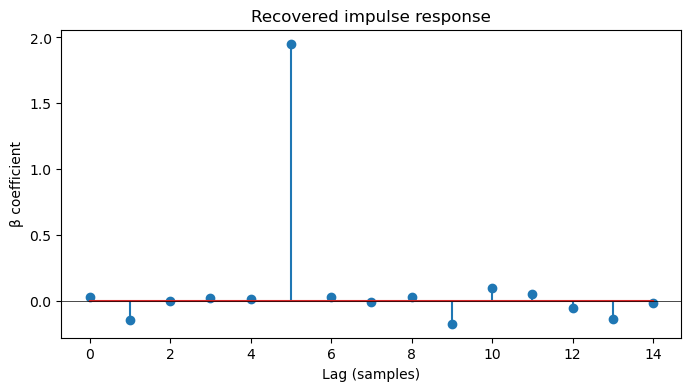

In [2]:
np.random.seed(42)
n = 500  # Time points

# Simulate a stimulus time series
stimulus = np.random.randn(n)

# Simulate a response that depends on stimulus at lag 5
# (like a neural response delayed ~50ms at 100Hz sampling)
true_lag = 5
response = np.roll(stimulus, true_lag) * 2 + np.random.randn(n) * 0.5
response[:true_lag] = 0  # Clean up edge effects

# Try regression at different lags
lags = range(0, 15)
betas = []

for lag in lags:
    # Shift stimulus back by 'lag' samples
    stim_lagged = np.roll(stimulus, lag)
    
    # Simple regression: response ~ stimulus_lagged
    X = np.column_stack([np.ones(n), stim_lagged])
    beta = np.linalg.solve(X.T @ X, X.T @ response)
    betas.append(beta[1])

# Plot: this reveals the "impulse response"
plt.figure(figsize=(8, 4))
plt.stem(lags, betas)
plt.axhline(0, color='k', linewidth=0.5)
plt.xlabel('Lag (samples)')
plt.ylabel('β coefficient')
plt.title('Recovered impulse response')


Text(0.5, 1.0, 'TRF (all lags fitted simultaneously)')

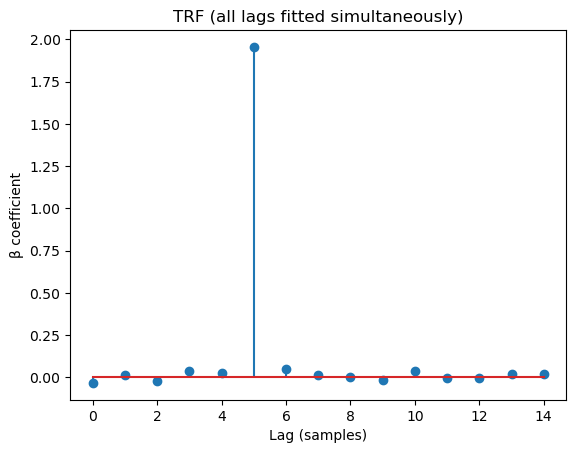

In [3]:
# Build design matrix with multiple lags
max_lag = 15
X_lagged = np.column_stack([np.roll(stimulus, lag) for lag in range(max_lag)])
X_lagged = np.column_stack([np.ones(n), X_lagged])  # Add intercept

# Now OLS (or Ridge) gives you the full TRF at once
beta_trf = np.linalg.solve(X_lagged.T @ X_lagged, X_lagged.T @ response)

plt.stem(range(max_lag), beta_trf[1:])  # Skip intercept
plt.xlabel('Lag (samples)')
plt.ylabel('β coefficient')
plt.title('TRF (all lags fitted simultaneously)')
